# Pandas Practice: The Iris Dataset

In this notebook you will independently apply everything from `01_Introduction_to_Pandas.ipynb` and `03_Introduction_to_Visualization.ipynb` to a new dataset. The **Iris dataset** is one of the most widely used datasets in data science — it contains measurements (in centimetres) of 150 iris flowers across three species. Your goal is to load it, explore it, answer questions with code, and visualise your findings.

---

![Iris species](../images/iris.png)

---

In [1]:
from ctypes import kind

# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Part 1 — Exploring the Data

### Challenge 1: Preview and inspect

Display the first 5 rows and the last 10 rows of the DataFrame.

In [2]:
# YOUR CODE HERE
print(df.head(5))
print(df.tail(10))


   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
     sepal_length  sepal_width  petal_length  petal_width         species
140           6.7          3.1           5.6          2.4  Iris-virginica
141           6.9          3.1           5.1          2.3  Iris-virginica
142           5.8          2.7           5.1          1.9  Iris-virginica
143           6.8          3.2           5.9          2.3  Iris-virginica
144           6.7          3.3           5.7          2.5  Iris-virginica
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virg

### Challenge 2: How many irises are in the dataset?

How many rows and columns does the DataFrame have?

In [3]:
# YOUR CODE HERE
df.shape

(150, 5)

### Challenge 3: How many species are there?

Find out how many distinct species exist in the dataset, and what they are called.

In [5]:
# YOUR CODE HERE
df['species'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

---

## Part 2 — Statistics

### Challenge 4: Descriptive statistics for petal length

Calculate the mean, median, and mode for `petal_length`. What can you conclude about the distribution?

In [10]:
# YOUR CODE HERE
print(df['petal_length'].mean())
print(df['petal_length'].median())
print(df['petal_length'].mode())

3.758666666666666
4.35
0    1.5
Name: petal_length, dtype: float64


### Challenge 5: Range and spread

What is the smallest and largest value for `petal_length`? Calculate the variance and standard deviation.

In [13]:
# YOUR CODE HERE
print(df['petal_length'].var())
df.describe()['petal_length']

3.113179418344519


count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64

### Challenge 6: Full summary

Use a single command to get the basic descriptive statistics for all columns.

In [ ]:
# YOUR CODE HERE
# like above

### Challenge 7: Overall average sepal length

What is the average `sepal_length` across all 150 flowers?

In [14]:
# YOUR CODE HERE
df['sepal_length'].mean()

np.float64(5.843333333333334)

---

## Part 3 — Groupby

### Challenge 8: Count by species

Use `groupby` to count the number of observations for each species.

In [15]:
# YOUR CODE HERE
df.groupby('species').count()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


### Challenge 9: Average measurements by species

Use `groupby` to find the average `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` for each species.

In [16]:
# YOUR CODE HERE
print(df.groupby('species')['sepal_length'].mean())
print(df.groupby('species')['sepal_width'].mean())
print(df.groupby('species')['petal_length'].mean())
print(df.groupby('species')['petal_width'].mean())

species
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: sepal_length, dtype: float64
species
Iris-setosa        3.418
Iris-versicolor    2.770
Iris-virginica     2.974
Name: sepal_width, dtype: float64
species
Iris-setosa        1.464
Iris-versicolor    4.260
Iris-virginica     5.552
Name: petal_length, dtype: float64
species
Iris-setosa        0.244
Iris-versicolor    1.326
Iris-virginica     2.026
Name: petal_width, dtype: float64


---

## Part 4 — Column Operations and Filtering

### Challenge 10: Add a new column

Create a new column `sepal_total` that is the sum of `sepal_width` and `sepal_length`.

In [18]:
# YOUR CODE HERE
df.eval("sepal_total = sepal_width + sepal_length", inplace=True)

### Challenge 11: Add petal area

Create a new column `petal_area` as a rough estimate of petal area: `petal_length × petal_width`.

In [19]:
# YOUR CODE HERE
df.eval("petal_area = petal_width * petal_length", inplace=True)

### Challenge 12: Filter by petal area

Create a new DataFrame containing only the flowers where `petal_area` is greater than 1 cm².

In [28]:
# YOUR CODE HERE
df.query("petal_area > 1")

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,9.7,11.96
146,6.3,2.5,5.0,1.9,Iris-virginica,8.8,9.50
147,6.5,3.0,5.2,2.0,Iris-virginica,9.5,10.40
148,6.2,3.4,5.4,2.3,Iris-virginica,9.6,12.42


### Challenge 13: Split by species

Create three separate DataFrames — one for each species — using the full dataset.

In [34]:
# YOUR CODE HERE

df.query("species == 'Iris-versicolor'")
df.query("species == 'Iris-setosa'")
df.query("species == 'Iris-virginica'")



,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
100,6.3,3.3,6.0,2.5,Iris-virginica,9.6,15.00
101,5.8,2.7,5.1,1.9,Iris-virginica,8.5,9.69
102,7.1,3.0,5.9,2.1,Iris-virginica,10.1,12.39
103,6.3,2.9,5.6,1.8,Iris-virginica,9.2,10.08
104,6.5,3.0,5.8,2.2,Iris-virginica,9.5,12.76
105,7.6,3.0,6.6,2.1,Iris-virginica,10.6,13.86
106,4.9,2.5,4.5,1.7,Iris-virginica,7.4,7.65
107,7.3,2.9,6.3,1.8,Iris-virginica,10.2,11.34
108,6.7,2.5,5.8,1.8,Iris-virginica,9.2,10.44
109,7.2,3.6,6.1,2.5,Iris-virginica,10.8,15.25


---

## Part 5 — Visualisation

### Challenge 14: Histogram of petal length

Create a histogram of `petal_length`. Describe the distribution — is it symmetric, skewed, or does it appear to have multiple peaks?

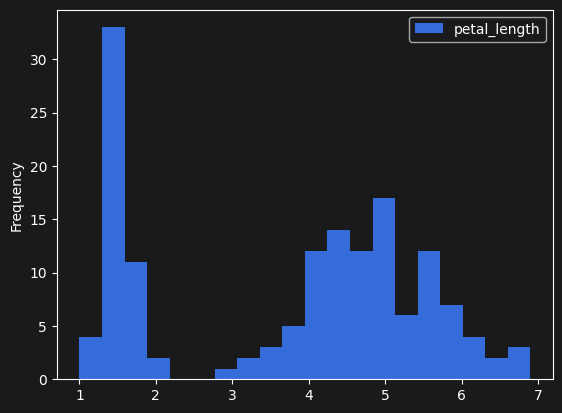

In [36]:
# YOUR CODE HERE
df.plot(
    kind='hist',
    y='petal_length',
    bins=20,
)
plt.show()

### Challenge 15: Scatter matrix of petal dimensions

Create a scatter plot of `petal_length` vs `petal_width`. Do larger petals tend to be longer as well?

> Bonus: use `pd.plotting.scatter_matrix(df)` to see all pairwise relationships at once.

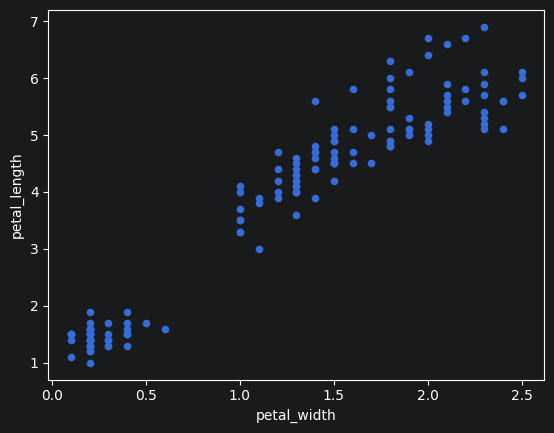

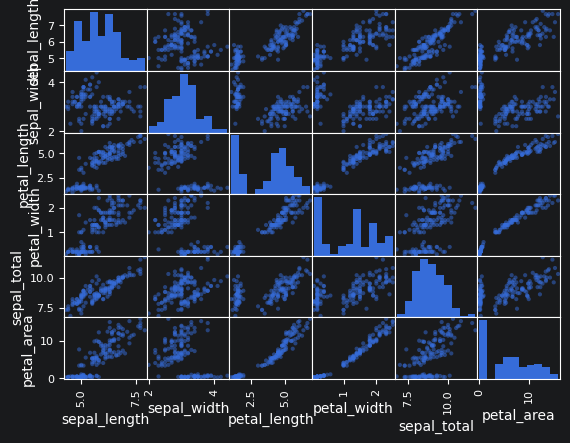

In [38]:
# YOUR CODE HERE
df.plot(
    kind='scatter',
    x='petal_width',
    y='petal_length',
)
plt.show()
pd.plotting.scatter_matrix(df)
plt.show()